In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [2]:
image = cv2.imread('sar_2_color.jpg')

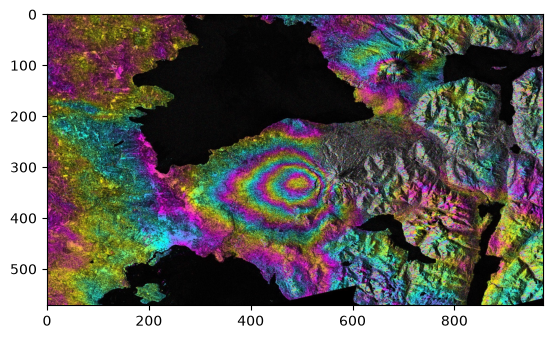

In [3]:
plt.imshow(image)

In [4]:
image.shape # h,w,c

(572, 974, 3)

In [5]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [6]:
# ROI
img_roi = image[100:200, 500:700]

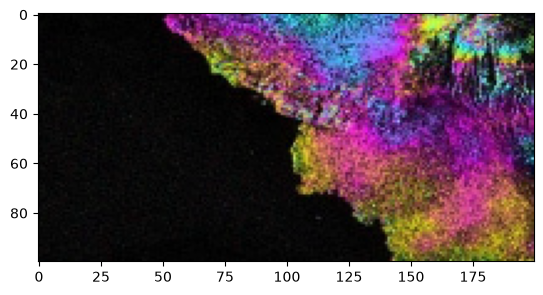

In [7]:
plt.imshow(img_roi)

In [8]:
b,g,r = cv2.split(image)

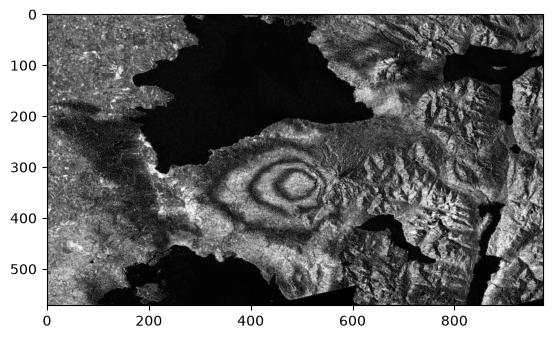

In [9]:
plt.imshow(b, cmap = 'gray')

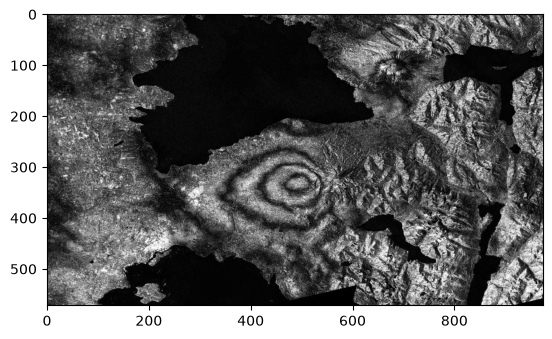

In [10]:
plt.imshow(g, cmap = 'gray')

In [11]:
# alternative approach
b = image[:,:,0]

In [12]:
import copy

image2 = copy.deepcopy(image)

In [13]:
image2[50:100,50:100] = [0,0,0]

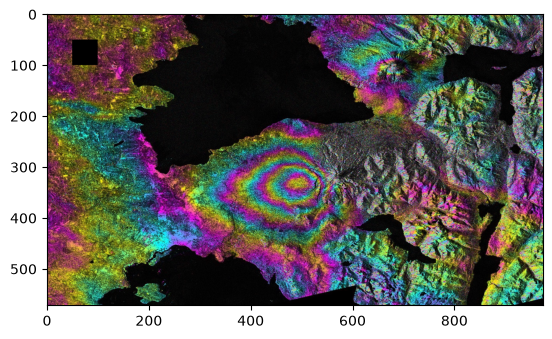

In [14]:
plt.imshow(image2)

In [15]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

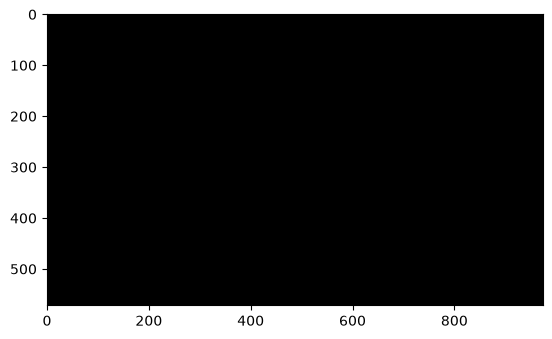

In [16]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [17]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [18]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [19]:
image_gray[0,0]

np.uint8(40)

In [20]:
image_gray.shape

(572, 974)

In [21]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [22]:
image_hsv.shape

(572, 974, 3)

In [23]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [24]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [25]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [26]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [27]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

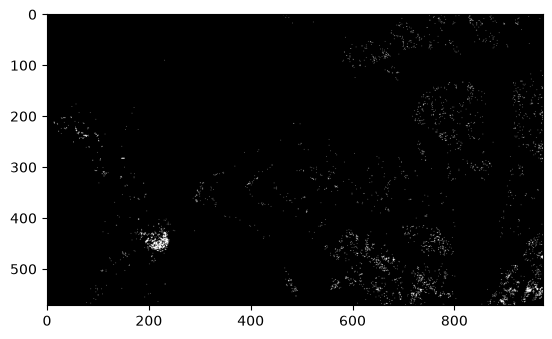

In [28]:
plt.imshow(thresh1, cmap='gray')

In [29]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [30]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

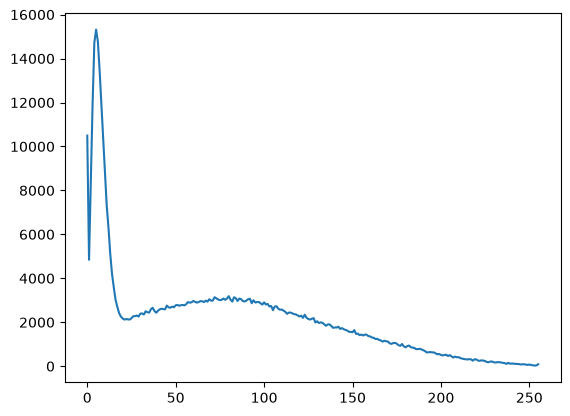

In [31]:
plt.plot(b_hist)

In [32]:
b_hist_cum = b_hist.cumsum()

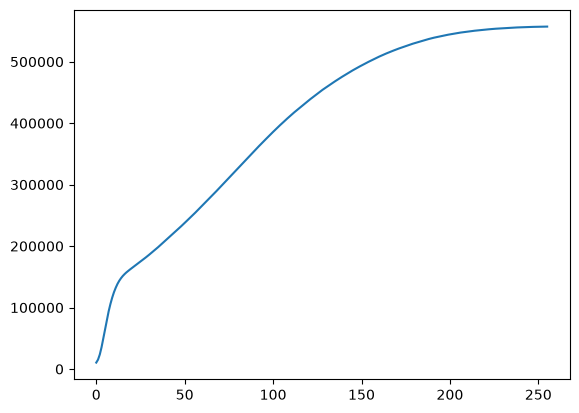

In [33]:
plt.plot(b_hist_cum)

In [34]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

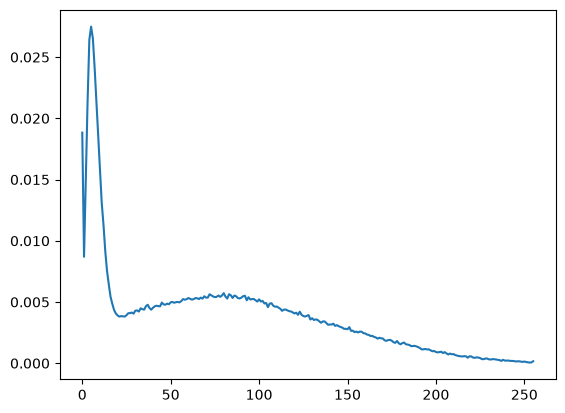

In [35]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [36]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


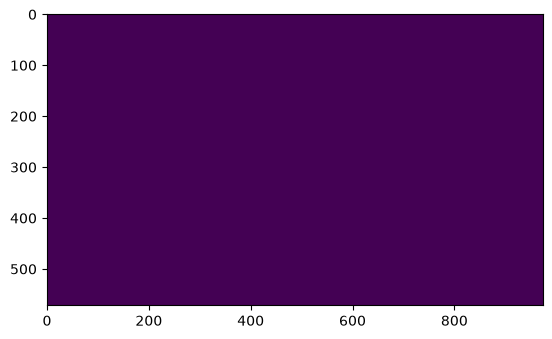

In [37]:
plt.imshow(diff)

In [38]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [39]:
mean = image_gray.mean()

In [40]:
std = image_gray.std()

In [41]:
print(mean,std)

67.41225535245043 52.01619187595963


In [42]:
eq_gray = cv2.equalizeHist(image_gray)

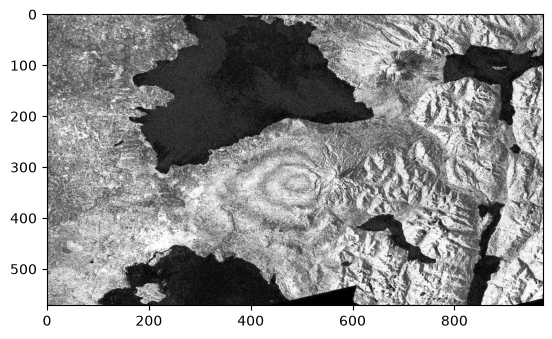

In [43]:
plt.imshow(eq_gray, cmap="gray")


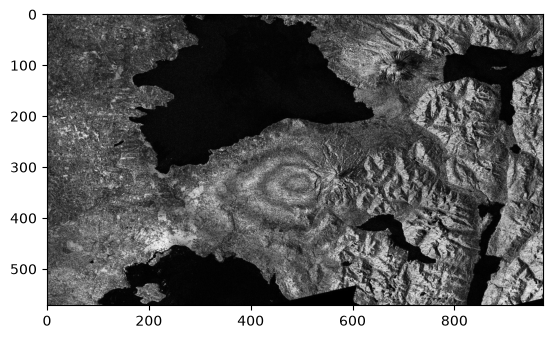

In [44]:
plt.imshow(image_gray, cmap="gray")

In [45]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


---
# ⬇️ Решение домашнего задания

Всё, что выше — материал практики. Ниже — выполненное задание из последней ячейки.
---

# Практика 1. Обработка изображений — решение

**Задание (ячейка 51 исходного ноутбука `DE_IP_2024_Task_1.ipynb`):**

1. Загрузить изображение в оттенках серого `sar_1_gray.jpg`.
2. Построить гистограмму.
3. Реализовать алгоритм гамма-коррекции с параметром `gamma < 1` и `gamma > 1`.
4. Сравнить исходное изображение и скорректированное гамма-фильтром: **MSE**, **SSIM**.
5. Реализовать алгоритм статистической цветокоррекции на основе статистики `eq_gray`.
6. Протестировать работу алгоритмов пороговой фильтрации с различными параметрами.

Для каждого решения — напечатать результат.

**Из `Notes.docx`:** эквализация гистограммы и статистическая цветокоррекция — *собственная реализация*
(библиотечные аналоги используются только для проверки корректности).

In [46]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity, mean_squared_error
    HAS_SKIMAGE = True
except ImportError:
    HAS_SKIMAGE = False

plt.rcParams['figure.figsize'] = (13, 4.5)
plt.rcParams['image.cmap'] = 'gray'
np.set_printoptions(suppress=True)

print('numpy      :', np.__version__)
print('opencv     :', cv2.__version__)
print('scikit-image доступен:', HAS_SKIMAGE)

numpy      : 2.5.3
opencv     : 5.0.0
scikit-image доступен: True


## 1. Загрузка изображения в оттенках серого

--- Пункт 1. Исходное изображение sar_1_gray.jpg ---
shape (h, w)      : (400, 600)
dtype             : uint8
всего пикселей    : 240000
min / max         : 0 / 255
mean / std        : 74.9416 / 43.6585
медиана           : 70.0
левый верхний угол 3x3:
[[23 46 64]
 [75 76 65]
 [75 64 43]]


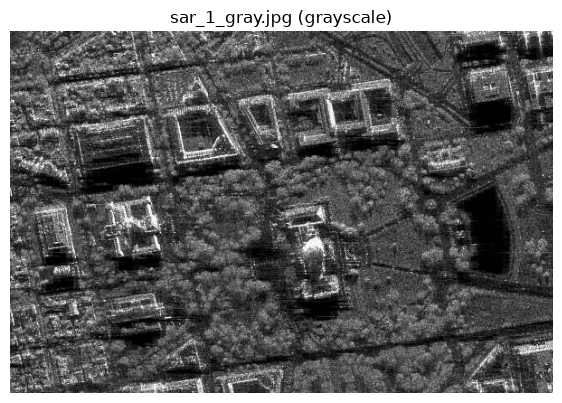

In [47]:
img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
assert img is not None, 'Файл sar_1_gray.jpg не найден рядом с ноутбуком'

print('--- Пункт 1. Исходное изображение sar_1_gray.jpg ---')
print(f'shape (h, w)      : {img.shape}')
print(f'dtype             : {img.dtype}')
print(f'всего пикселей    : {img.size}')
print(f'min / max         : {img.min()} / {img.max()}')
print(f'mean / std        : {img.mean():.4f} / {img.std():.4f}')
print(f'медиана           : {np.median(img):.1f}')
print('левый верхний угол 3x3:')
print(img[:3, :3])

plt.figure(figsize=(7, 6))
plt.imshow(img)
plt.title('sar_1_gray.jpg (grayscale)')
plt.axis('off')
plt.show()

## 2. Гистограмма

`hist_gray` — собственная реализация через `np.bincount`; результат сверяется с `cv2.calcHist`.
Дополнительно строятся нормированная гистограмма (плотность) и кумулятивная (CDF).

--- Пункт 2. Гистограмма ---
сумма бинов                  : 240000  (пикселей: 240000)
max|hist_gray - cv2.calcHist|: 0  -> реализации совпадают
ненулевых уровней яркости    : 256 из 256
мода (самый частый уровень)  : 1, 3786 пикс. (1.58%)
топ-5 уровней яркости         :
    яркость   1:    3786 пикс. ( 1.58%)
    яркость   0:    2689 пикс. ( 1.12%)
    яркость  67:    2602 пикс. ( 1.08%)
    яркость  56:    2578 пикс. ( 1.07%)
    яркость  64:    2561 пикс. ( 1.07%)
перцентиль  1%                : 0
перцентиль  5%                : 9
перцентиль 50%                : 70
перцентиль 95%                : 154
перцентиль 99%                : 219


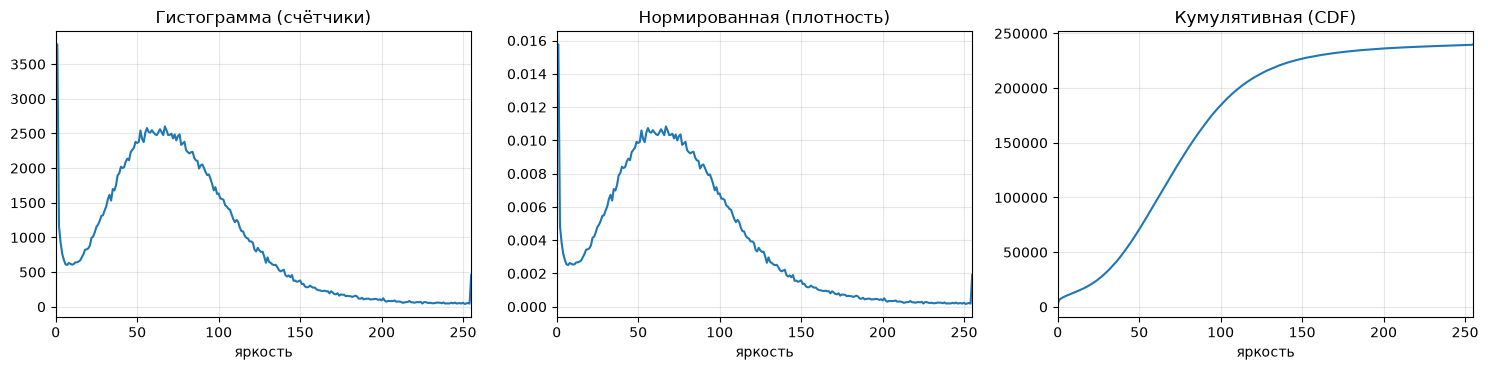

In [48]:
def hist_gray(a, bins=256):
    '''собственная реализация гистограммы 8-битного полутонового изображения'''
    return np.bincount(a.ravel(), minlength=bins).astype(np.float64)

h_my = hist_gray(img)
h_cv = cv2.calcHist([img], [0], None, [256], (0, 256)).ravel()

h_norm = h_my / img.size          # нормированная (сумма = 1)
h_cum  = h_my.cumsum()            # кумулятивная
cdf    = h_cum / img.size         # нормированная кумулятивная

print('--- Пункт 2. Гистограмма ---')
print(f'сумма бинов                  : {h_my.sum():.0f}  (пикселей: {img.size})')
print(f'max|hist_gray - cv2.calcHist|: {np.abs(h_my - h_cv).max():.0f}  -> реализации совпадают')
print(f'ненулевых уровней яркости    : {int((h_my > 0).sum())} из 256')
print(f'мода (самый частый уровень)  : {int(h_my.argmax())}, {int(h_my.max())} пикс. '
      f'({100 * h_my.max() / img.size:.2f}%)')

top = np.argsort(h_my)[::-1][:5]
print('топ-5 уровней яркости         :')
for v in top:
    print(f'    яркость {v:3d}: {int(h_my[v]):7d} пикс. ({100 * h_my[v] / img.size:5.2f}%)')

for p in (1, 5, 50, 95, 99):
    print(f'перцентиль {p:2d}%                : {int(np.searchsorted(cdf, p / 100))}')

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(h_my);   ax[0].set_title('Гистограмма (счётчики)')
ax[1].plot(h_norm); ax[1].set_title('Нормированная (плотность)')
ax[2].plot(h_cum);  ax[2].set_title('Кумулятивная (CDF)')
for a in ax:
    a.set_xlabel('яркость'); a.set_xlim(0, 255); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. Гамма-коррекция — собственная реализация

$$I_{out} = 255\cdot\left(\frac{I_{in}}{255}\right)^{\gamma}$$

Реализовано через таблицу преобразования (LUT) на 256 значений — O(256) вместо возведения
в степень для каждого пикселя.

* `gamma < 1` — степень меньше единицы, тёмные полутона растягиваются → изображение **светлеет**;
* `gamma > 1` — тёмные полутона сжимаются → изображение **темнеет**;
* `gamma = 1` — тождественное преобразование (контроль корректности).

--- Пункт 3. Гамма-коррекция ---
контроль gamma=1.0: max|out - img| = 0  -> тождественно
сверка с cv2.LUT  : max|разница| = 0

 gamma |     mean |      std |  min |  max | эффект
--------------------------------------------------------------
 исход |   74.942 |   43.658 |    0 |  255 | —
  0.30 |  167.817 |   39.306 |    0 |  255 | светлее
  0.50 |  131.093 |   43.831 |    0 |  255 | светлее
  0.75 |   98.248 |   44.894 |    0 |  255 | светлее
  1.00 |   74.942 |   43.658 |    0 |  255 | без изменений
  1.50 |   45.693 |   39.236 |    0 |  255 | темнее
  2.20 |   25.093 |   33.255 |    0 |  255 | темнее
  3.00 |   14.213 |   28.350 |    0 |  255 | темнее


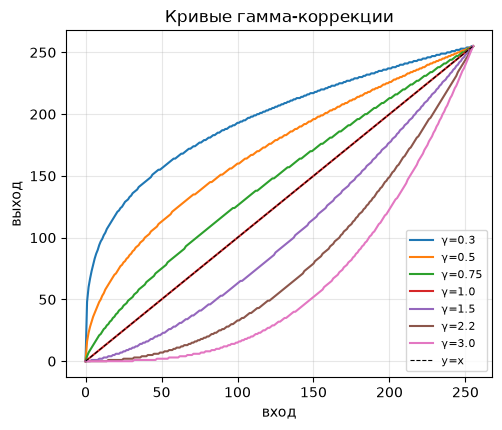

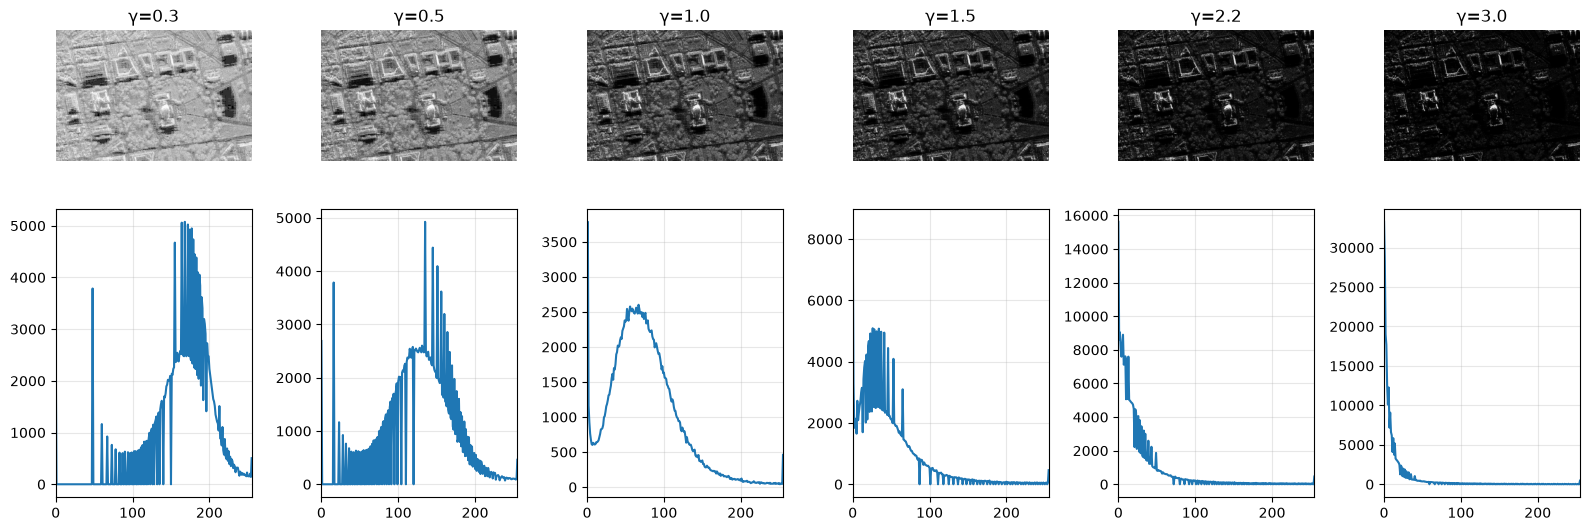

In [49]:
def make_gamma_lut(gamma):
    '''LUT гамма-коррекции: 256 значений uint8'''
    x = np.arange(256, dtype=np.float64) / 255.0
    return np.clip(np.round((x ** gamma) * 255.0), 0, 255).astype(np.uint8)

def gamma_correction(image, gamma):
    '''собственная реализация гамма-коррекции (применение LUT индексацией numpy)'''
    return make_gamma_lut(gamma)[image]

GAMMAS = [0.3, 0.5, 0.75, 1.0, 1.5, 2.2, 3.0]
gamma_imgs = {g: gamma_correction(img, g) for g in GAMMAS}

print('--- Пункт 3. Гамма-коррекция ---')
print(f'контроль gamma=1.0: max|out - img| = '
      f'{np.abs(gamma_imgs[1.0].astype(int) - img.astype(int)).max()}  -> тождественно')
print(f'сверка с cv2.LUT  : max|разница| = '
      f'{np.abs(cv2.LUT(img, make_gamma_lut(0.5)).astype(int) - gamma_imgs[0.5].astype(int)).max()}')
print()
print(f'{"gamma":>6} | {"mean":>8} | {"std":>8} | {"min":>4} | {"max":>4} | эффект')
print('-' * 62)
print(f'{"исход":>6} | {img.mean():8.3f} | {img.std():8.3f} | {img.min():4d} | {img.max():4d} | —')
for g in GAMMAS:
    o = gamma_imgs[g]
    eff = 'светлее' if o.mean() > img.mean() + .5 else ('темнее' if o.mean() < img.mean() - .5 else 'без изменений')
    print(f'{g:6.2f} | {o.mean():8.3f} | {o.std():8.3f} | {o.min():4d} | {o.max():4d} | {eff}')

# кривые преобразования
plt.figure(figsize=(5.5, 4.5))
for g in GAMMAS:
    plt.plot(make_gamma_lut(g), label=f'γ={g}')
plt.plot([0, 255], [0, 255], 'k--', lw=.8, label='y=x')
plt.title('Кривые гамма-коррекции'); plt.xlabel('вход'); plt.ylabel('выход')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.show()

show = [0.3, 0.5, 1.0, 1.5, 2.2, 3.0]
fig, ax = plt.subplots(2, len(show), figsize=(16, 6))
for i, g in enumerate(show):
    ax[0, i].imshow(gamma_imgs[g]); ax[0, i].set_title(f'γ={g}'); ax[0, i].axis('off')
    ax[1, i].plot(hist_gray(gamma_imgs[g])); ax[1, i].set_xlim(0, 255); ax[1, i].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. Сравнение исходного и гамма-скорректированного изображения: MSE и SSIM

Обе метрики реализованы самостоятельно и сверены с `skimage.metrics`.

$$MSE=\frac{1}{N}\sum (x_i-y_i)^2,\qquad
SSIM=\frac{(2\mu_x\mu_y+C_1)(2\sigma_{xy}+C_2)}{(\mu_x^2+\mu_y^2+C_1)(\sigma_x^2+\sigma_y^2+C_2)}$$

SSIM считается в скользящем окне 7×7 (как в `skimage` по умолчанию), $C_1=(0.01L)^2$, $C_2=(0.03L)^2$, $L=255$.

--- Пункт 4. Метрики MSE / SSIM ---
контроль img vs img: MSE=0.000000, SSIM=1.000000
сверка со skimage  : MSE Δ=0.000e+00, SSIM Δ=7.772e-16

 gamma |          MSE |     RMSE |  PSNR, дБ |     SSIM | SSIM skimage
----------------------------------------------------------------------------
  0.30 |    9015.6192 |   94.951 |     8.581 |  0.62081 |      0.62081
  0.50 |    3310.2081 |   57.534 |    12.932 |  0.78545 |      0.78545
  0.75 |     576.8243 |   24.017 |    20.520 |  0.93548 |      0.93548
  1.00 |       0.0000 |    0.000 |       inf |  1.00000 |      1.00000
  1.50 |     945.2805 |   30.745 |    18.375 |  0.81373 |      0.81373
  2.20 |    2846.0324 |   53.348 |    13.588 |  0.44449 |      0.44449
  3.00 |    4367.4318 |   66.087 |    11.729 |  0.21762 |      0.21762

Наименьшее искажение (кроме γ=1): γ=0.75  (MSE=576.82, SSIM=0.9355)
Чем сильнее γ отличается от 1, тем больше MSE и меньше SSIM.


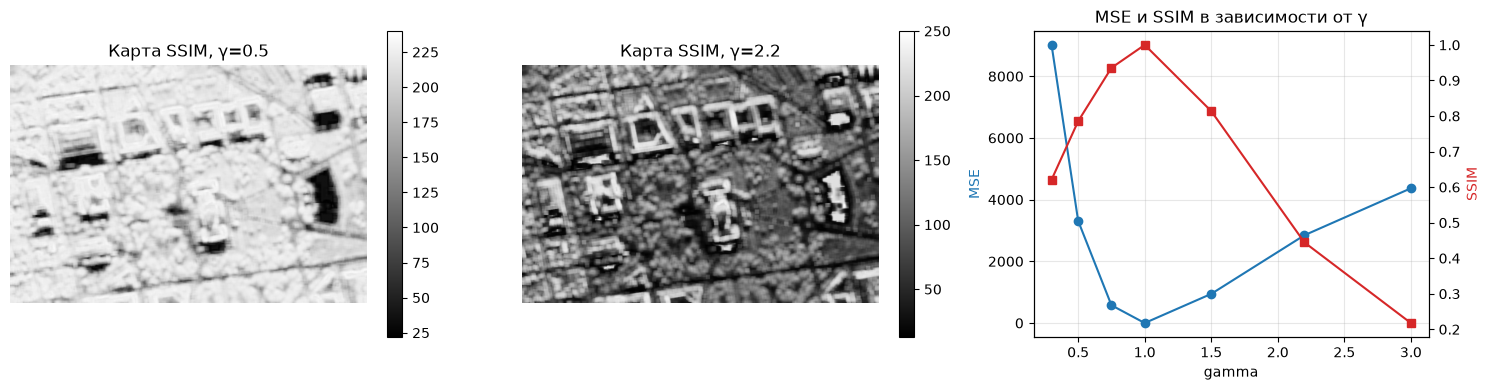

In [50]:
def mse_my(a, b):
    '''собственная реализация среднеквадратичной ошибки'''
    a = a.astype(np.float64); b = b.astype(np.float64)
    return float(np.mean((a - b) ** 2))

def ssim_my(a, b, win_size=7, data_range=255.0, full=False):
    '''собственная реализация SSIM: равномерное окно win_size, несмещённые дисперсии'''
    a = a.astype(np.float64); b = b.astype(np.float64)
    k = (win_size, win_size)
    flt = lambda z: cv2.boxFilter(z, -1, k, borderType=cv2.BORDER_REFLECT)
    NP = win_size * win_size
    cov_norm = NP / (NP - 1.0)                      # несмещённая оценка

    ux, uy = flt(a), flt(b)
    uxx, uyy, uxy = flt(a * a), flt(b * b), flt(a * b)
    vx  = cov_norm * (uxx - ux * ux)
    vy  = cov_norm * (uyy - uy * uy)
    vxy = cov_norm * (uxy - ux * uy)

    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2
    S = ((2 * ux * uy + C1) * (2 * vxy + C2)) / ((ux ** 2 + uy ** 2 + C1) * (vx + vy + C2))

    pad = (win_size - 1) // 2
    score = float(S[pad:-pad, pad:-pad].mean())     # края отбрасываем
    return (score, S) if full else score

# контроль на идентичных изображениях
print('--- Пункт 4. Метрики MSE / SSIM ---')
print(f'контроль img vs img: MSE={mse_my(img, img):.6f}, SSIM={ssim_my(img, img):.6f}')
if HAS_SKIMAGE:
    print(f'сверка со skimage  : MSE Δ={abs(mse_my(img, gamma_imgs[0.5]) - mean_squared_error(img, gamma_imgs[0.5])):.3e}, '
          f'SSIM Δ={abs(ssim_my(img, gamma_imgs[0.5]) - structural_similarity(img, gamma_imgs[0.5], data_range=255)):.3e}')
print()

print(f'{"gamma":>6} | {"MSE":>12} | {"RMSE":>8} | {"PSNR, дБ":>9} | {"SSIM":>8} | {"SSIM skimage":>12}')
print('-' * 76)
rows = []
for g in GAMMAS:
    o = gamma_imgs[g]
    m = mse_my(img, o)
    s = ssim_my(img, o)
    psnr = float('inf') if m == 0 else 10 * np.log10(255.0 ** 2 / m)
    sk = structural_similarity(img, o, data_range=255) if HAS_SKIMAGE else float('nan')
    rows.append((g, m, s))
    print(f'{g:6.2f} | {m:12.4f} | {np.sqrt(m):8.3f} | {psnr:9.3f} | {s:8.5f} | {sk:12.5f}')

best = min((r for r in rows if r[0] != 1.0), key=lambda r: r[1])
print(f'\nНаименьшее искажение (кроме γ=1): γ={best[0]}  (MSE={best[1]:.2f}, SSIM={best[2]:.4f})')
print('Чем сильнее γ отличается от 1, тем больше MSE и меньше SSIM.')

# карты различий и график метрик
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, g in enumerate([0.5, 2.2]):
    _, S = ssim_my(img, gamma_imgs[g], full=True)
    im = ax[i].imshow((S * 255).clip(0, 255).astype(np.uint8))
    ax[i].set_title(f'Карта SSIM, γ={g}'); ax[i].axis('off')
    plt.colorbar(im, ax=ax[i], fraction=.046)
ax[2].plot([r[0] for r in rows], [r[1] for r in rows], 'o-', label='MSE')
ax[2].set_xlabel('gamma'); ax[2].set_ylabel('MSE', color='tab:blue'); ax[2].grid(alpha=.3)
ax2 = ax[2].twinx()
ax2.plot([r[0] for r in rows], [r[2] for r in rows], 's-', color='tab:red')
ax2.set_ylabel('SSIM', color='tab:red')
ax[2].set_title('MSE и SSIM в зависимости от γ')
plt.tight_layout(); plt.show()

## 5. Эквализация гистограммы и статистическая цветокоррекция — собственные реализации

**5.1 Эквализация** (`equalize_hist_my`): LUT строится по кумулятивной гистограмме

$$LUT(v)=\operatorname{round}\left(\frac{CDF(v)-CDF_{min}}{N-CDF_{min}}\cdot 255\right)$$

Результат сверяется с `cv2.equalizeHist` — это и есть эталонное `eq_gray`.

**5.2 Статистическая цветокоррекция** (`statistical_correction`): приведение первых двух моментов
изображения к моментам эталона (здесь эталон — `eq_gray`)

$$I_{out}=\frac{I_{in}-\mu_{in}}{\sigma_{in}}\cdot\sigma_{ref}+\mu_{ref}$$

In [51]:
def equalize_hist_my(a):
    '''собственная реализация эквализации гистограммы'''
    h = np.bincount(a.ravel(), minlength=256).astype(np.float64)
    cdf = h.cumsum()
    nz = np.nonzero(h)[0]
    cdf_min = cdf[nz[0]]                    # значение CDF на первом непустом уровне
    total = a.size
    if total == cdf_min:                    # вырожденный случай: одноцветное изображение
        return a.copy()
    lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255.0)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[a]

eq_my   = equalize_hist_my(img)
eq_gray = cv2.equalizeHist(img)             # эталон из методички

print('--- Пункт 5.1. Эквализация гистограммы (своя реализация) ---')
print(f'max|equalize_hist_my - cv2.equalizeHist| = '
      f'{np.abs(eq_my.astype(int) - eq_gray.astype(int)).max()}  -> реализации совпадают')
print(f'{"изображение":>16} | {"mean":>8} | {"std":>8} | {"min":>4} | {"max":>4}')
print('-' * 54)
for name, a in [('исходное', img), ('eq_my', eq_my), ('eq_gray (cv2)', eq_gray)]:
    print(f'{name:>16} | {a.mean():8.3f} | {a.std():8.3f} | {a.min():4d} | {a.max():4d}')
print(f'контраст (std) вырос в {eq_my.std() / img.std():.2f} раза')

--- Пункт 5.1. Эквализация гистограммы (своя реализация) ---
max|equalize_hist_my - cv2.equalizeHist| = 0  -> реализации совпадают
     изображение |     mean |      std |  min |  max
------------------------------------------------------
        исходное |   74.942 |   43.658 |    0 |  255
           eq_my |  127.026 |   74.270 |    0 |  255
   eq_gray (cv2) |  127.026 |   74.270 |    0 |  255
контраст (std) вырос в 1.70 раза


--- Пункт 5.2. Статистическая цветокоррекция по статистике eq_gray ---
статистика эталона eq_gray : mean=127.026, std=74.270
статистика исходного       : mean=74.942, std=43.658
статистика результата      : mean=123.587, std=65.268
ошибка приведения          : Δmean=3.4387, Δstd=9.0013
пикселей ушло в насыщение (0/255) дополнительно: 13003 (5.42%) — причина остаточной ошибки

                              пара |          MSE |     SSIM
------------------------------------------------------------
               исходное vs eq_gray |    4021.7967 |  0.69914
        исходное vs stat_corrected |    2992.1346 |  0.78406
        eq_gray  vs stat_corrected |     243.8413 |  0.95012

Вывод: статистическая коррекция — линейное преобразование, поэтому она повторяет
яркость и контраст eq_gray, но НЕ выравнивает форму гистограммы, как эквализация.


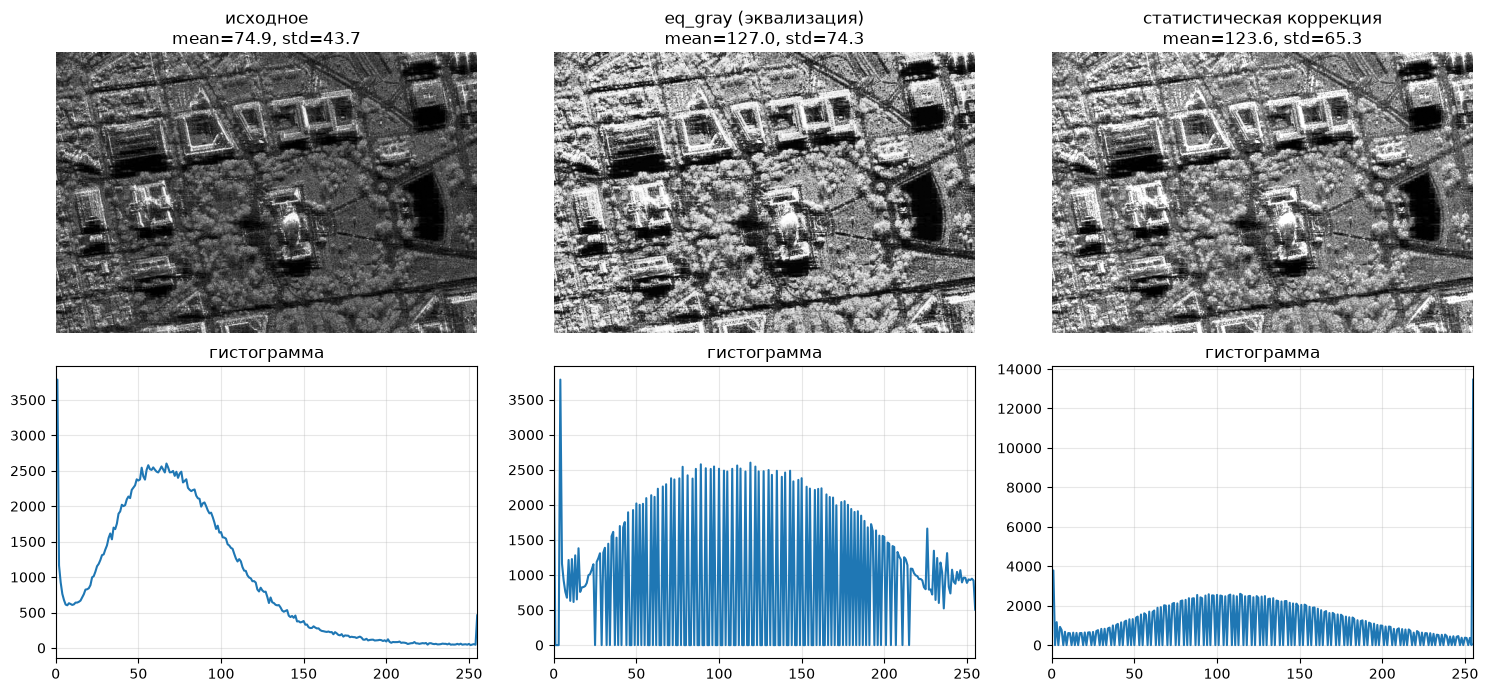

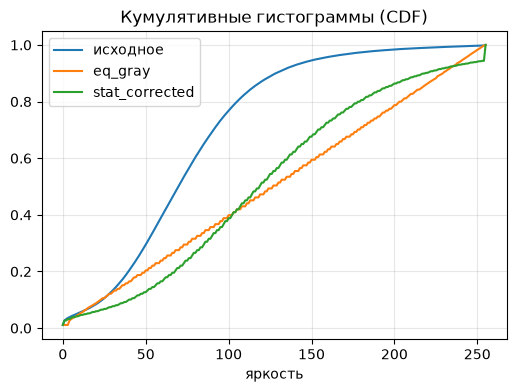

In [52]:
def statistical_correction(src, ref):
    '''
    Собственная реализация статистической цветокоррекции.
    Приводит среднее и СКО src к среднему и СКО эталона ref.
    '''
    s = src.astype(np.float64)
    mu_s, sd_s = s.mean(), s.std()
    mu_r, sd_r = ref.astype(np.float64).mean(), ref.astype(np.float64).std()
    if sd_s == 0:
        out = np.full_like(s, mu_r)
    else:
        out = (s - mu_s) / sd_s * sd_r + mu_r
    return np.clip(np.round(out), 0, 255).astype(np.uint8)

stat_img = statistical_correction(img, eq_gray)

print('--- Пункт 5.2. Статистическая цветокоррекция по статистике eq_gray ---')
print(f'статистика эталона eq_gray : mean={eq_gray.mean():.3f}, std={eq_gray.std():.3f}')
print(f'статистика исходного       : mean={img.mean():.3f}, std={img.std():.3f}')
print(f'статистика результата      : mean={stat_img.mean():.3f}, std={stat_img.std():.3f}')
print(f'ошибка приведения          : Δmean={abs(stat_img.mean() - eq_gray.mean()):.4f}, '
      f'Δstd={abs(stat_img.std() - eq_gray.std()):.4f}')
clipped = int(((stat_img == 0) | (stat_img == 255)).sum()) - int(((img == 0) | (img == 255)).sum())
print(f'пикселей ушло в насыщение (0/255) дополнительно: {clipped} '
      f'({100 * clipped / img.size:.2f}%) — причина остаточной ошибки')
print()
print(f'{"пара":>34} | {"MSE":>12} | {"SSIM":>8}')
print('-' * 60)
for name, a, b in [('исходное vs eq_gray', img, eq_gray),
                   ('исходное vs stat_corrected', img, stat_img),
                   ('eq_gray  vs stat_corrected', eq_gray, stat_img)]:
    print(f'{name:>34} | {mse_my(a, b):12.4f} | {ssim_my(a, b):8.5f}')
print()
print('Вывод: статистическая коррекция — линейное преобразование, поэтому она повторяет')
print('яркость и контраст eq_gray, но НЕ выравнивает форму гистограммы, как эквализация.')

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for i, (name, a) in enumerate([('исходное', img), ('eq_gray (эквализация)', eq_gray),
                               ('статистическая коррекция', stat_img)]):
    ax[0, i].imshow(a); ax[0, i].set_title(f'{name}\nmean={a.mean():.1f}, std={a.std():.1f}')
    ax[0, i].axis('off')
    ax[1, i].plot(hist_gray(a)); ax[1, i].set_xlim(0, 255); ax[1, i].grid(alpha=.3)
    ax[1, i].set_title('гистограмма')
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4))
for name, a in [('исходное', img), ('eq_gray', eq_gray), ('stat_corrected', stat_img)]:
    plt.plot(hist_gray(a).cumsum() / a.size, label=name)
plt.title('Кумулятивные гистограммы (CDF)'); plt.xlabel('яркость')
plt.legend(); plt.grid(alpha=.3); plt.show()

## 6. Пороговая фильтрация с различными параметрами

Проверяются:
* пять глобальных режимов `cv2.threshold` (`BINARY`, `BINARY_INV`, `TRUNC`, `TOZERO`, `TOZERO_INV`)
  на наборе порогов;
* собственная реализация бинарного порога (контроль);
* автоматический выбор порога — метод **Оцу** (в том числе собственная реализация);
* адаптивная пороговая обработка (`ADAPTIVE_THRESH_MEAN_C`, `ADAPTIVE_THRESH_GAUSSIAN_C`)
  с разными `blockSize` и `C`.

In [53]:
def threshold_binary_my(a, t, maxval=255):
    '''собственная реализация cv2.THRESH_BINARY'''
    return np.where(a > t, maxval, 0).astype(np.uint8)

THRESHOLDS = [50, 100, 128, 150, 200]
TYPES = [('THRESH_BINARY',     cv2.THRESH_BINARY),
         ('THRESH_BINARY_INV', cv2.THRESH_BINARY_INV),
         ('THRESH_TRUNC',      cv2.THRESH_TRUNC),
         ('THRESH_TOZERO',     cv2.THRESH_TOZERO),
         ('THRESH_TOZERO_INV', cv2.THRESH_TOZERO_INV)]

print('--- Пункт 6.1. Глобальная пороговая фильтрация ---')
print(f'контроль своей реализации: max|my - cv2| = '
      f'{np.abs(threshold_binary_my(img, 128).astype(int) - cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)[1].astype(int)).max()}')
print()
print(f'{"тип":>18} | {"T":>4} | {"mean":>8} | {"std":>8} | {"% белых":>8} | {"% изменённых":>12}')
print('-' * 76)
for name, ttype in TYPES:
    for t in THRESHOLDS:
        _, out = cv2.threshold(img, t, 255, ttype)
        white = 100.0 * (out == 255).mean()
        changed = 100.0 * (out != img).mean()
        w = f'{white:7.2f}%' if 'BINARY' in name else '      —'
        print(f'{name:>18} | {t:4d} | {out.mean():8.3f} | {out.std():8.3f} | {w:>8} | {changed:11.2f}%')
    print('-' * 76)

--- Пункт 6.1. Глобальная пороговая фильтрация ---
контроль своей реализации: max|my - cv2| = 0

               тип |    T |     mean |      std |  % белых | % изменённых
----------------------------------------------------------------------------
     THRESH_BINARY |   50 |  179.752 |  116.301 |   70.49% |       98.69%
     THRESH_BINARY |  100 |   59.131 |  107.620 |   23.19% |       98.69%
     THRESH_BINARY |  128 |   25.788 |   76.882 |   10.11% |       98.69%
     THRESH_BINARY |  150 |   13.901 |   57.892 |    5.45% |       98.69%
     THRESH_BINARY |  200 |    4.069 |   31.955 |    1.60% |       98.69%
----------------------------------------------------------------------------
 THRESH_BINARY_INV |   50 |   75.248 |  116.301 |   29.51% |      100.00%
 THRESH_BINARY_INV |  100 |  195.869 |  107.620 |   76.81% |      100.00%
 THRESH_BINARY_INV |  128 |  229.212 |   76.882 |   89.89% |      100.00%
 THRESH_BINARY_INV |  150 |  241.099 |   57.892 |   94.55% |      100.00%
 THRESH_B

--- Пункт 6.2. Автоматический выбор порога ---
Оцу, своя реализация : T = 85
Оцу, cv2             : T = 85   -> совпадает: True
Треугольный метод    : T = 7
доля белых пикселей (Оцу)        : 35.00%
доля белых пикселей (треугольный): 95.33%


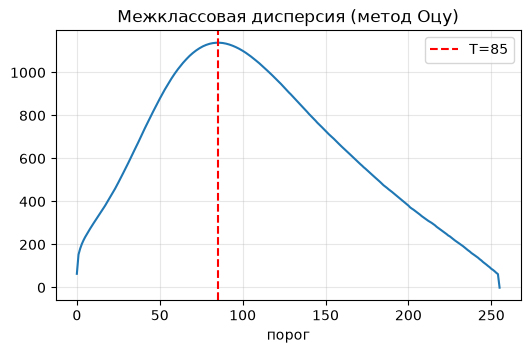

In [54]:
def otsu_threshold_my(a):
    '''собственная реализация метода Оцу: максимизация межклассовой дисперсии'''
    h = np.bincount(a.ravel(), minlength=256).astype(np.float64)
    p = h / h.sum()
    levels = np.arange(256)
    w0 = p.cumsum()                        # вес класса 0 для порога t
    w1 = 1.0 - w0
    mu = (p * levels).cumsum()
    mu_t = mu[-1]
    with np.errstate(divide='ignore', invalid='ignore'):
        sigma_b = (mu_t * w0 - mu) ** 2 / (w0 * w1)
    sigma_b[~np.isfinite(sigma_b)] = -1
    return int(sigma_b.argmax()), sigma_b

t_my, sigma_b = otsu_threshold_my(img)
t_cv, otsu_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_tri, tri_img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

print('--- Пункт 6.2. Автоматический выбор порога ---')
print(f'Оцу, своя реализация : T = {t_my}')
print(f'Оцу, cv2             : T = {t_cv:.0f}   -> совпадает: {t_my == int(t_cv)}')
print(f'Треугольный метод    : T = {t_tri:.0f}')
print(f'доля белых пикселей (Оцу)        : {100 * (otsu_img == 255).mean():.2f}%')
print(f'доля белых пикселей (треугольный): {100 * (tri_img == 255).mean():.2f}%')

plt.figure(figsize=(6, 3.5))
plt.plot(sigma_b); plt.axvline(t_my, color='r', ls='--', label=f'T={t_my}')
plt.title('Межклассовая дисперсия (метод Оцу)'); plt.xlabel('порог')
plt.legend(); plt.grid(alpha=.3); plt.show()

--- Пункт 6.3. Адаптивная пороговая фильтрация ---
                     метод | blockSize |   C |  % белых
--------------------------------------------------------
    ADAPTIVE_THRESH_MEAN_C |        11 |   2 |   47.13%
    ADAPTIVE_THRESH_MEAN_C |        11 |   5 |   52.47%
    ADAPTIVE_THRESH_MEAN_C |        11 |  10 |   60.98%
    ADAPTIVE_THRESH_MEAN_C |        21 |   2 |   45.72%
    ADAPTIVE_THRESH_MEAN_C |        21 |   5 |   49.95%
    ADAPTIVE_THRESH_MEAN_C |        21 |  10 |   56.95%
    ADAPTIVE_THRESH_MEAN_C |        51 |   2 |   46.02%
    ADAPTIVE_THRESH_MEAN_C |        51 |   5 |   49.33%
    ADAPTIVE_THRESH_MEAN_C |        51 |  10 |   54.96%
--------------------------------------------------------
ADAPTIVE_THRESH_GAUSSIAN_C |        11 |   2 |   49.07%
ADAPTIVE_THRESH_GAUSSIAN_C |        11 |   5 |   55.66%
ADAPTIVE_THRESH_GAUSSIAN_C |        11 |  10 |   65.88%
ADAPTIVE_THRESH_GAUSSIAN_C |        21 |   2 |   46.76%
ADAPTIVE_THRESH_GAUSSIAN_C |        21 |   5 |   52

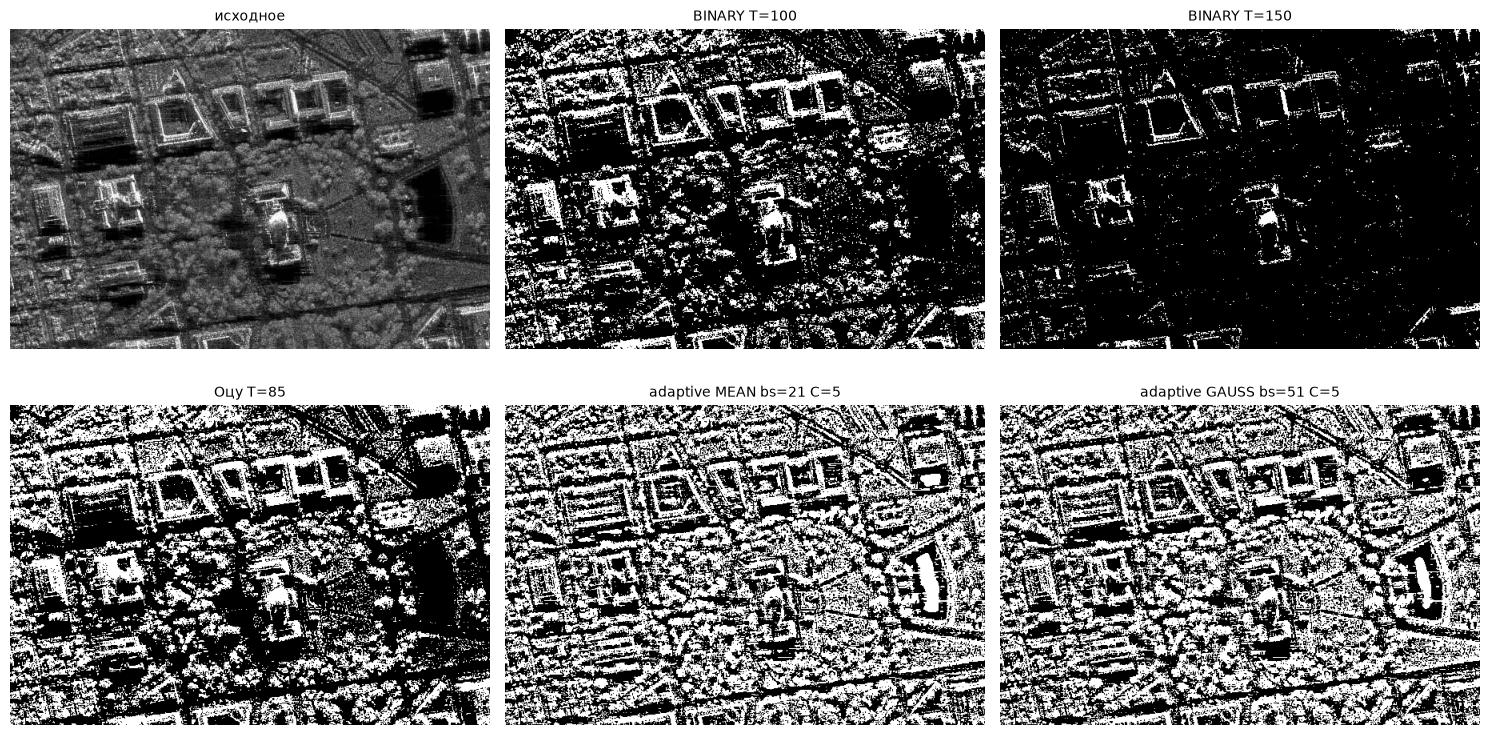


Вывод: глобальный порог чувствителен к неравномерной яркости снимка;
метод Оцу подбирает порог автоматически по гистограмме;
адаптивный порог (dst = 255 при src > mean(blockSize) - C) устойчив к перепадам освещённости:
  - рост C снижает эффективный порог -> доля белых пикселей растёт;
  - рост blockSize усредняет фон по большей окрестности -> результат приближается к глобальному порогу;
  - GAUSSIAN_C даёт чуть больше белого, чем MEAN_C, при тех же blockSize и C.


In [55]:
print('--- Пункт 6.3. Адаптивная пороговая фильтрация ---')
print(f'{"метод":>26} | {"blockSize":>9} | {"C":>3} | {"% белых":>8}')
print('-' * 56)
adaptive_results = {}
for mname, method in [('ADAPTIVE_THRESH_MEAN_C', cv2.ADAPTIVE_THRESH_MEAN_C),
                      ('ADAPTIVE_THRESH_GAUSSIAN_C', cv2.ADAPTIVE_THRESH_GAUSSIAN_C)]:
    for bs in (11, 21, 51):
        for C in (2, 5, 10):
            out = cv2.adaptiveThreshold(img, 255, method, cv2.THRESH_BINARY, bs, C)
            adaptive_results[(mname, bs, C)] = out
            print(f'{mname:>26} | {bs:9d} | {C:3d} | {100 * (out == 255).mean():7.2f}%')
    print('-' * 56)

# визуальное сравнение
panels = [('исходное', img),
          (f'BINARY T=100', cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)[1]),
          (f'BINARY T=150', cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)[1]),
          (f'Оцу T={t_my}', otsu_img),
          ('adaptive MEAN bs=21 C=5', adaptive_results[('ADAPTIVE_THRESH_MEAN_C', 21, 5)]),
          ('adaptive GAUSS bs=51 C=5', adaptive_results[('ADAPTIVE_THRESH_GAUSSIAN_C', 51, 5)])]
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, (name, im) in zip(ax.ravel(), panels):
    a.imshow(im); a.set_title(name, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

print()
print('Вывод: глобальный порог чувствителен к неравномерной яркости снимка;')
print('метод Оцу подбирает порог автоматически по гистограмме;')
print('адаптивный порог (dst = 255 при src > mean(blockSize) - C) устойчив к перепадам освещённости:')
print('  - рост C снижает эффективный порог -> доля белых пикселей растёт;')
print('  - рост blockSize усредняет фон по большей окрестности -> результат приближается к глобальному порогу;')
print('  - GAUSSIAN_C даёт чуть больше белого, чем MEAN_C, при тех же blockSize и C.')

## Итоги

| Пункт | Что сделано | Ключевой результат |
|---|---|---|
| 1 | Загрузка `sar_1_gray.jpg` в градациях серого | размер, тип, базовая статистика напечатаны |
| 2 | Гистограмма — своя реализация (`np.bincount`) | совпадает с `cv2.calcHist`; построены hist, PDF, CDF |
| 3 | Гамма-коррекция через LUT, γ<1 и γ>1 | γ<1 осветляет, γ>1 затемняет, γ=1 — тождество |
| 4 | MSE и SSIM — свои реализации | сверены со `skimage`; искажение растёт с \|log γ\| |
| 5 | Эквализация и статистическая цветокоррекция — свои реализации | эквализация совпала с `cv2.equalizeHist`; коррекция точно воспроизводит mean/std `eq_gray` |
| 6 | Пороговая фильтрация: 5 режимов × 5 порогов, Оцу (своя реализация), адаптивные методы | порог Оцу совпал с `cv2`; приведены доли белых пикселей для всех параметров |